# Human activity prediction 

### Project Authors:
- Davit Arabidze **Matriculation number:** 955477
- Temur Khvedelidze **Matriculation number:** 955494
- Nia Gogilidze **Matriculation number:** 955509

### Project goals:
- Organizing the given data into one dataset
- Evaluating the dataset and visualizing the data
- Processing and organizing data for training and testing
- Deciding on the architecture of a neural network for the given task
- Building, training and evaluating the Model

## Information about the dataset

[Link to the data set](https://archive-beta.ics.uci.edu/dataset/507/wisdm%2Bsmartphone%2Band%2Bsmartwatch%2Bactivity%2Band%2Bbiometrics%2Bdataset?utm_source=chatgpt.com)

The raw accelerometer and gyroscope sensor data is collected from the smartphone at a rate of **20Hz**. It is collected from **51 test subjects** as they perform **18 activities** for **3 minutes apiece**. The raw sensor data for the given sensors is stored inside 2 seperate directories (accel, gyro), which are the subdirectories of **phone** direcory. In each directory there are **51 files** corresponding to the **51 test subjects**. The format of every entry is the same: <subject-id, activity-code, timestamp, x, y, z>.

### Activities and their corresponding activity-codes:
| Activity      | Code |
| ----------- | ----------- |
| walking      | A      |
| jogging     | B       |
| stairs      | C      |
| sitting      | D      |
| standing      | E       |
| typing      |  F       |
| teeth      | G       |
| soup      | H       |
| chips      | I       |
| pasta      | J       |
| drinking      | K       |
| sandwich      | L       |
| kicking      | M       |
| catch      | O       |
| dribbling      | P       |
| writing      | Q       |
| clapping      | R       |
| folding      | S       |


## Structure of the project

### For ease of understanding we divided this project file into parts
- In the first part we solve the problem of organizing data. As mentioned, we have 2 seperate directories full of subject activity files that need merging. with techniques, which are discussed in this part, we managed to unite all of the files into one csv file and for the reminder of the project we used that same file.
- Second part is dedicated to Visualising the data and geting it ready for model training.
- Third and the final part is building the suitable model, training it on the dataset and evaluating it's performance.

#### Important note:
since part 1 of the project is only creating a csv file for later use, there is no need to execute it's code.


## PART 0: Importing important packages

In [106]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pathlib import Path

## PART 1: Data merging

As mentioned, We have 2 directories, **accel** and **gyro**, each containing 51 files.

**Below we provide visual repesentation of what these file structures look like**

|subject-id|activity-code|timestamp|x|y|z|
|----------|-------------|---------|-|-|-|
|1600|A|252207666810782|-0.36476135|8.793503|1.0550842|
|1600|A|252207717164786|-0.8797302|9.768784|1.0169983|
|1600|A|252207918580802|-4.332779|13.361191|-0.7188721|

Our goal is to merge accel and gyro files based on timestamps and activity codes. However accel activity timestamps dont align with gyro's timestamps before and after certain points. Below is the solution of how we dealt with that problem.

**filter_to_shared_range** function is a helper function, which gets a dataframe, timestamp minimum and maximum bounds and value columns for coordinates. The function basically iterates over df_bounds, gets activity and min/max timestamps and builds a mask where **True** means that given row is in range and has the chosen activity. And after building the mask we use it to filter the df dataframe.

In [ ]:
def filter_to_shared_range(df,df_bounds,val_cols):
    parts = []
    df_bounds = df_bounds.reset_index()
    for _,row in df_bounds.iterrows():
        activity = row['activity_code']
        t_min = row['min_timestamp']
        t_max = row['max_timestamp']

        mask = (df['activity_code'] == activity) & (df['timestamp'] >= t_min) & (df['timestamp'] <= t_max)

        parts.append(df.loc[mask,['user_id','activity_code','timestamp']+val_cols])
    return pd.concat(parts,ignore_index=True)

**filter_and_merge_sensors** is the function which filters 2 accel and gyro files with the help of previous function and merges them together. First, the function gets paths of 2 desired accel and gyro files, then it generates 2 dataframes and finds minimum and maximum bounds for each activity in each file and places them in **acc_bounds** and **gy_bounds**. After this, we join them together and create final df_bounds dataframe where each activity_code has its own minimum and maximum timestamp. Lastly we pass the necessary parameters to helper function and get filtered dataframes for gyro and accel. Finally we merge them together based on timestamps and activity_code and sort the final dataframe.

In [3]:


def filter_and_merge_sensors(accel_path, gyro_path):
    acc_column_names = ['user_id','activity_code','timestamp','ax','ay','az']
    gy_column_names = ['user_id','activity_code','timestamp','gx','gy','gz']
    acc_df = pd.read_csv(accel_path,header=None, names=acc_column_names)
    gy_df =  pd.read_csv(gyro_path,header=None, names=gy_column_names)

    acc_bounds = acc_df.groupby('activity_code')['timestamp'].agg(['min','max'])
    gy_bounds = gy_df.groupby('activity_code')['timestamp'].agg(['min','max'])

    bounds = acc_bounds.join(gy_bounds,lsuffix='_acc',rsuffix='_gy')

    df_bounds = pd.DataFrame(index=bounds.index)
    df_bounds['min_timestamp'] = bounds[['min_acc','min_gy']].max(axis=1)
    df_bounds['max_timestamp'] = bounds[['max_acc','max_gy']].min(axis=1)


    acc_filtered = filter_to_shared_range(acc_df,df_bounds,['ax','ay','az'])
    gy_filtered = filter_to_shared_range(gy_df,df_bounds,['gx','gy','gz'])


    merged_df = pd.merge(
        acc_filtered,
        gy_filtered.drop(columns='user_id'),
        on=[ 'activity_code', 'timestamp'],
    )

    merged_df = merged_df.sort_values(['activity_code','timestamp']).reset_index(drop=True)

    return merged_df

Code below calls the previous function in a loop which iterates over accel_file_names list and passes each file paths to the function, which returns dataframe and gets concatenated to the final **df**.

In [4]:
accel_path = Path('phone/accel')
acc_file_names = os.listdir(accel_path)
df = pd.concat((filter_and_merge_sensors(f'phone/accel/{filename}',f'phone/gyro/{filename.replace("accel","gyro")}')  for filename in acc_file_names ))
df = df.sort_values(['user_id','activity_code'],ascending=[True,True])

Below we clean up the *az* and *gz* column values which include ";" in them

In [5]:
df = df.astype(str).apply(lambda s: s.str.replace(';','',regex=False).str.strip())

numeric_cols = [
    'user_id',
    'timestamp',
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

And finally we convert the final dataframe into csv file for later use.

In [66]:
df.to_csv("merged_data.csv",index=False)


## PART 2: Data visualizing and preprocessing 

### PART 2.1: Data visualizing

#### First we load data from csv into a pandas dataframe

In [95]:
final_df = pd.read_csv("merged_data.csv")

#### let's check how the data frame looks and the shape of the data

In [6]:
final_df.head()

,user_id,activity_code,timestamp,ax,ay,az,gx,gy,gz
0,1600,A,252207918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
1,1600,A,252207968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
2,1600,A,252208019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
3,1600,A,252208069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
4,1600,A,252208119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135


In [7]:
final_df.shape

(2909149, 9)

We have 2909149 rows and 9 features. Most importantly it shows, that we have successfuly merged all of the accel and gyro files.

#### Now lets see what the data looks like

First lets define a function which visualizes sensor values based on the timestamp.

Function below first filters the final_df based on chosen user_id and activity_code, then creates 2 subplots for accel and gyro and visualizes x,y and z coordinates on them

In [ ]:
def visualize_sensors(sample_range,ac_code,user_id):
    df_user = final_df[(final_df['user_id'] == user_id) & (final_df['activity_code'] == ac_code)]
    _, axes = plt.subplots(2, 1, figsize=(12, 8))



    # Accelerometer
    for col in ['ax', 'ay', 'az']:
        axes[0].plot(df_user['timestamp'][:sample_range], df_user[col][:sample_range], label=col)
    axes[0].set_title(f'Accelerometer / Activity code: {ac_code} / User: {user_id}')
    axes[0].set_xlabel('Timestamp')
    axes[0].legend()

    # Gyroscope
    for col in ['gx', 'gy', 'gz']:
        axes[1].plot(df_user['timestamp'][:sample_range], df_user[col][:sample_range], label=col)
    axes[1].set_title(f'Gyroscope / Activity code: {ac_code} / User: {user_id}')
    axes[1].set_xlabel('Timestamp')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Now we can easly visualize data and compare each activities.
Let us look at the first three activity types from first three users 
| Activity      | Code |
| ----------- | ----------- |
| walking      | A      |
| jogging     | B       |
| stairs      | C      |

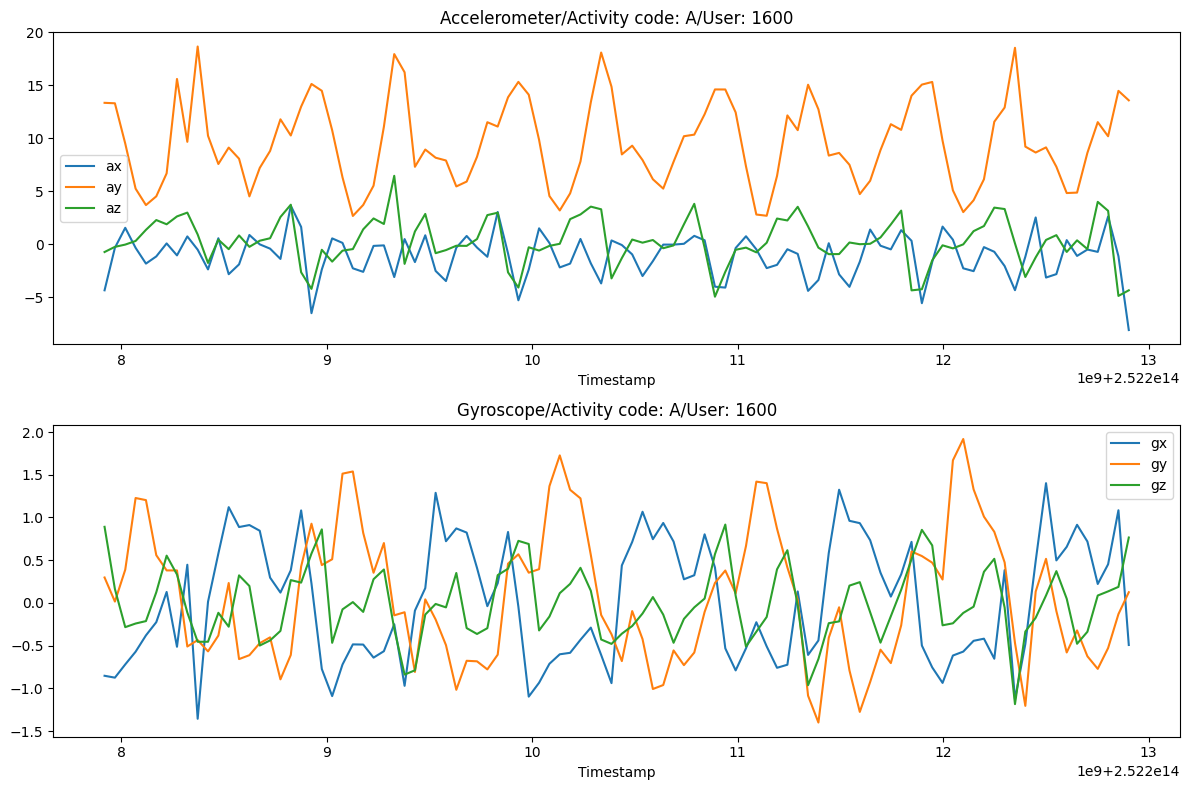

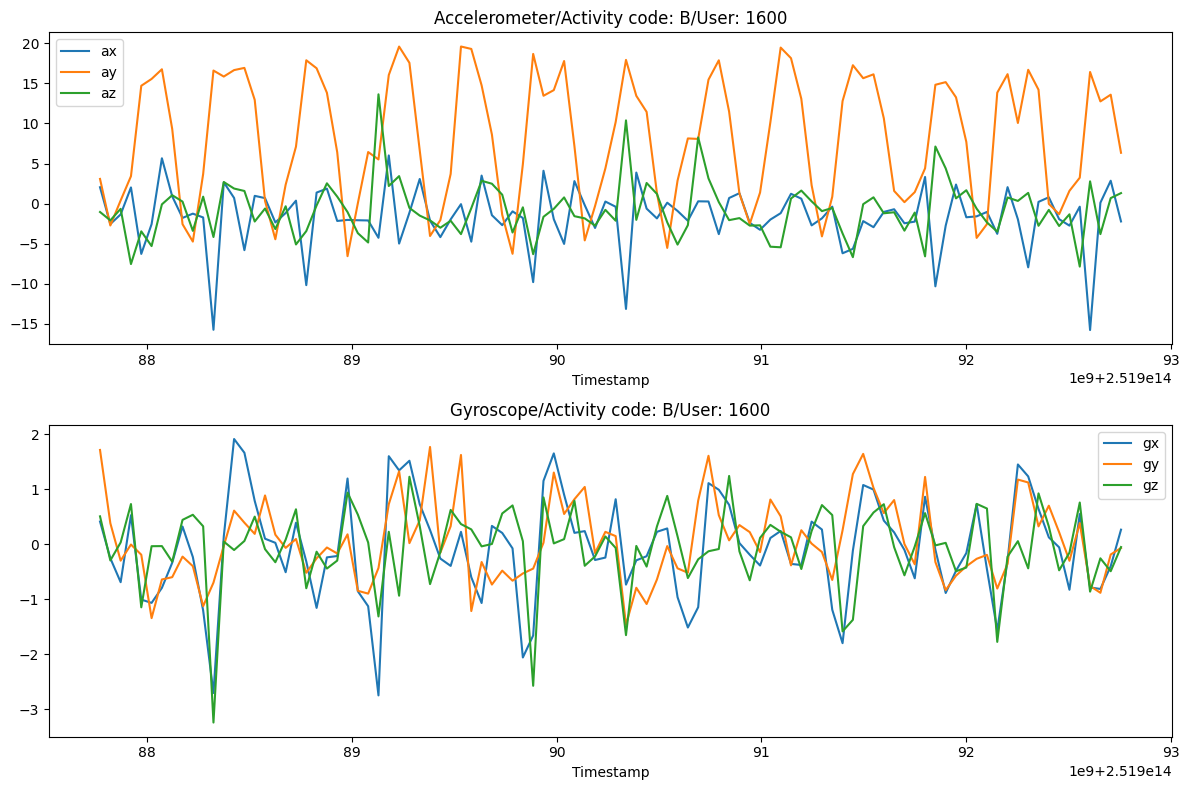

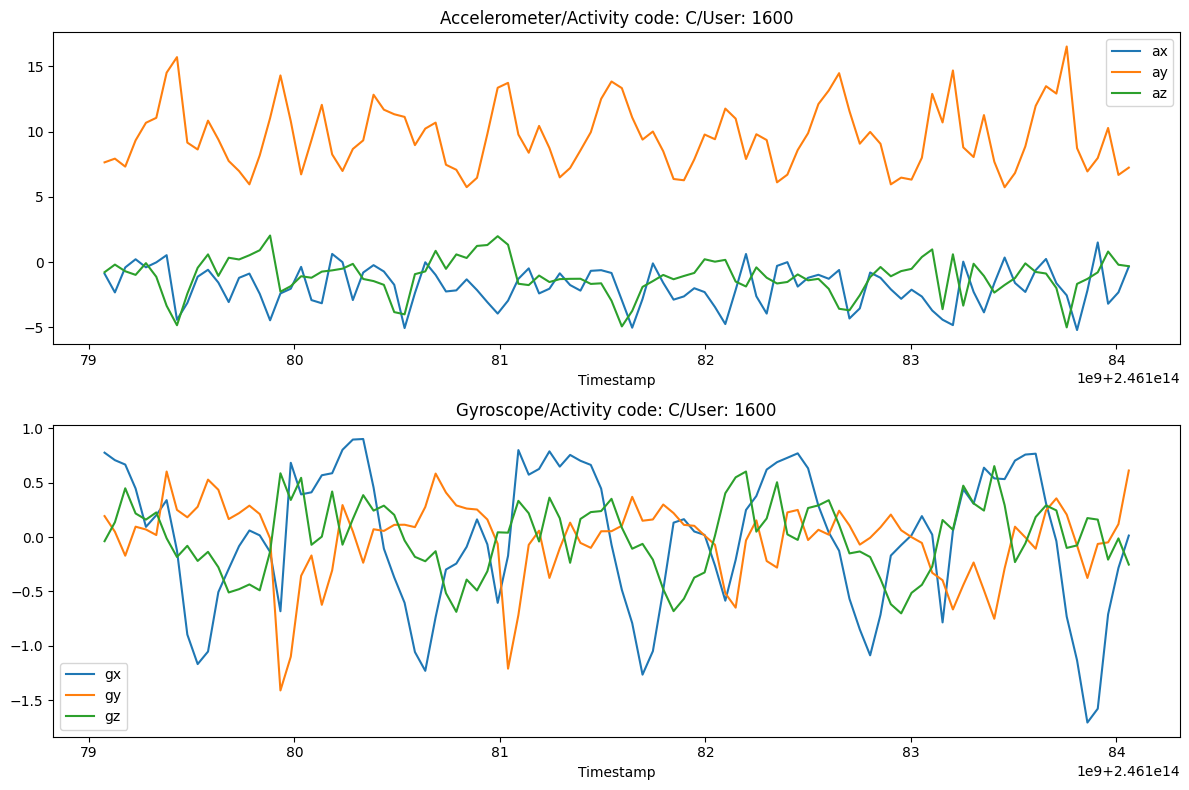

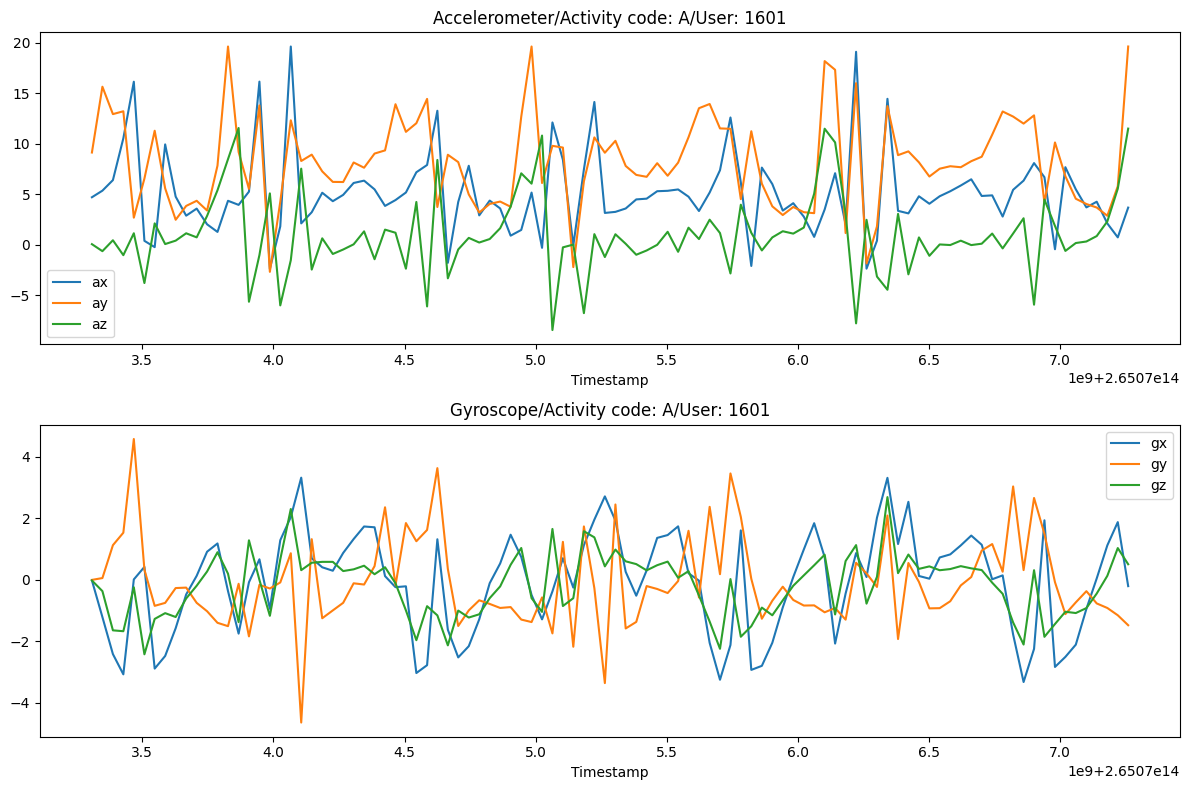

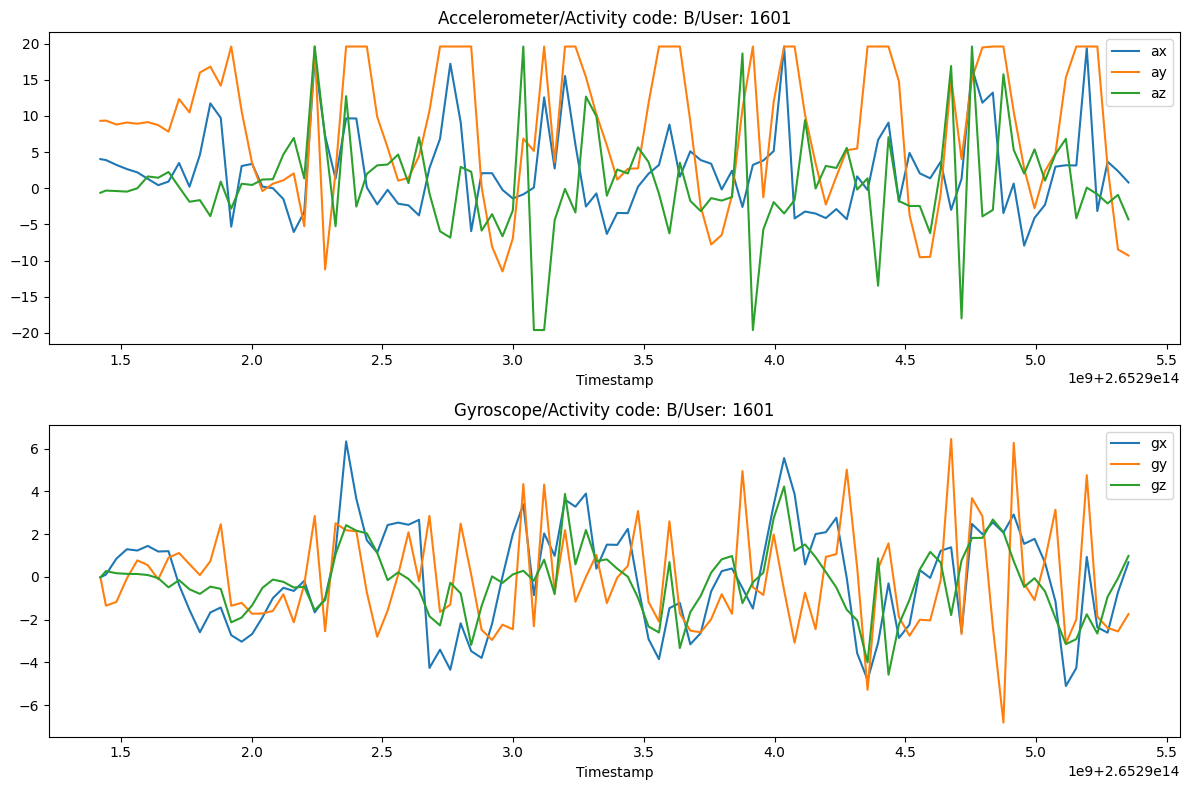

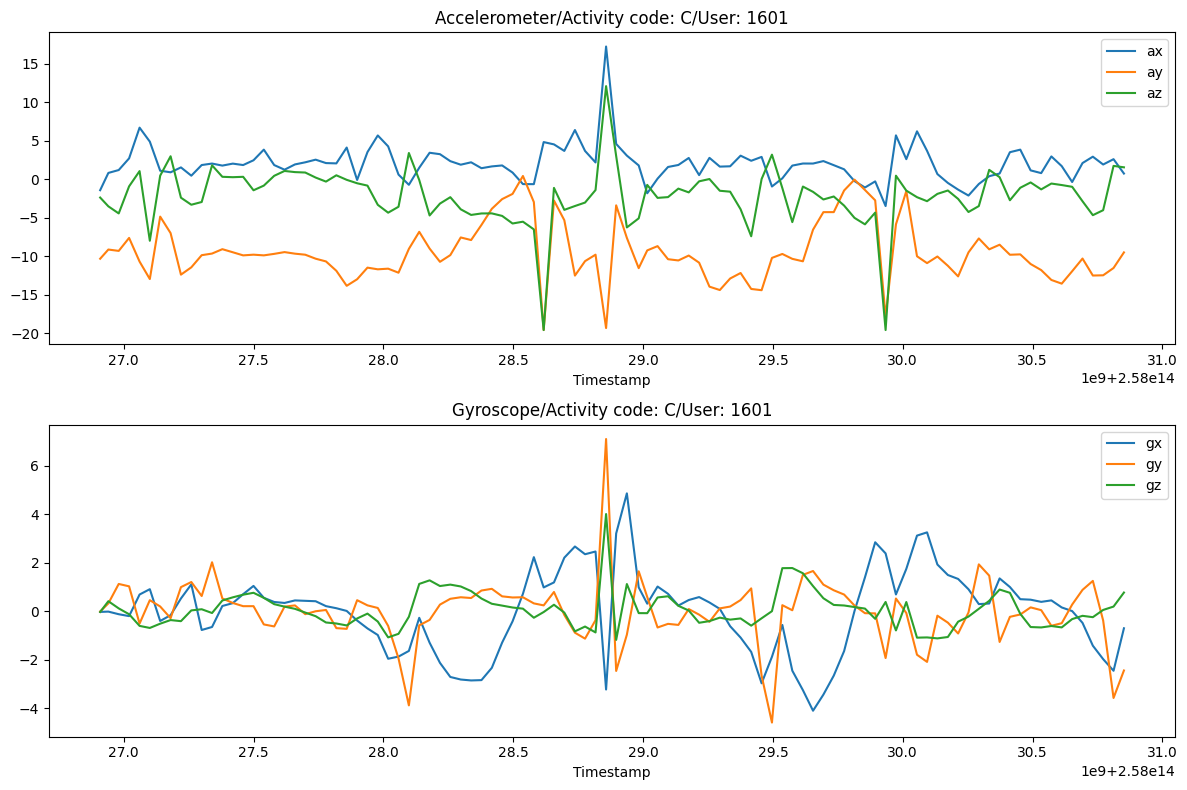

In [92]:
# walking, Jogging and climbing stares for user 1600
visualize_sensors(100,'A',1600)
visualize_sensors(100,'B',1600)
visualize_sensors(100,'C',1600)

# walking, Jogging and climbing stares for user 1601
visualize_sensors(100,'A',1601)
visualize_sensors(100,'B',1601)
visualize_sensors(100,'C',1601)

From the plots we can see that both users have similar patterns of walking, jogging and climbing stairs, Which indicates that there is a pettern to be learned here. 

All three activities demand a lot of movement, so let us see what it would look like if user for example ate chips.

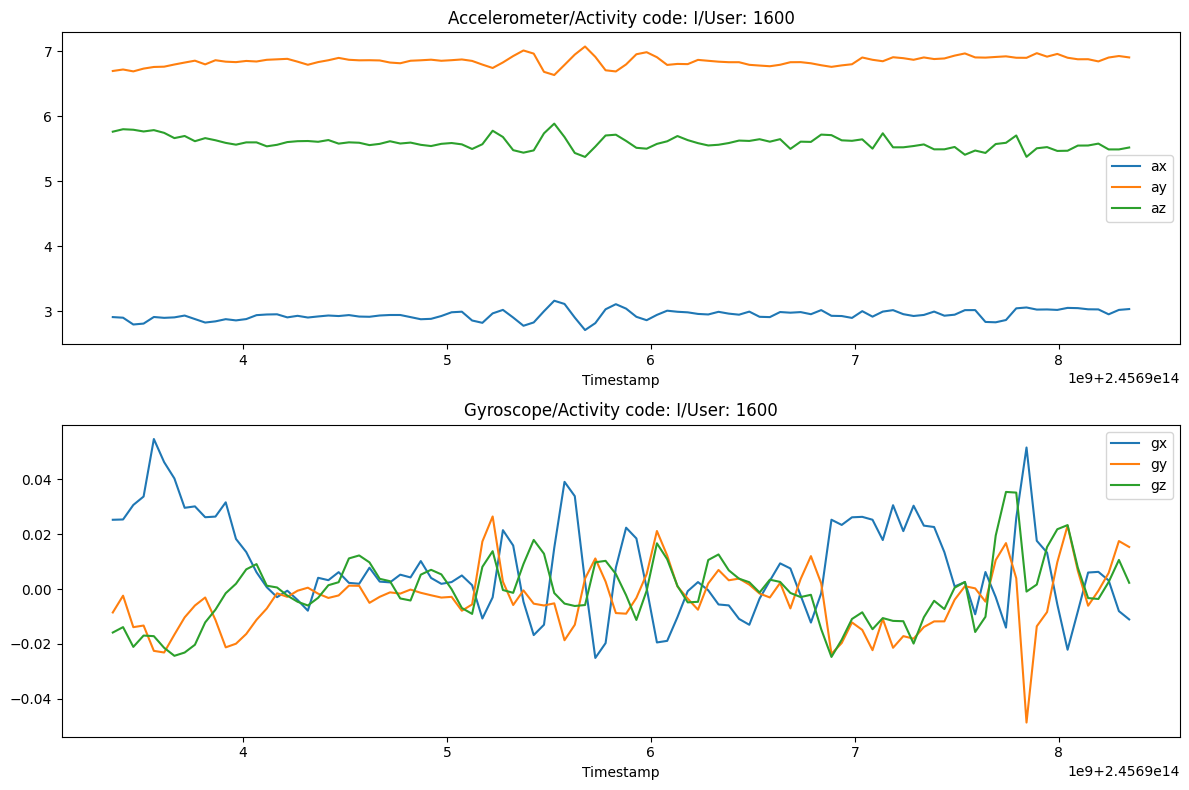

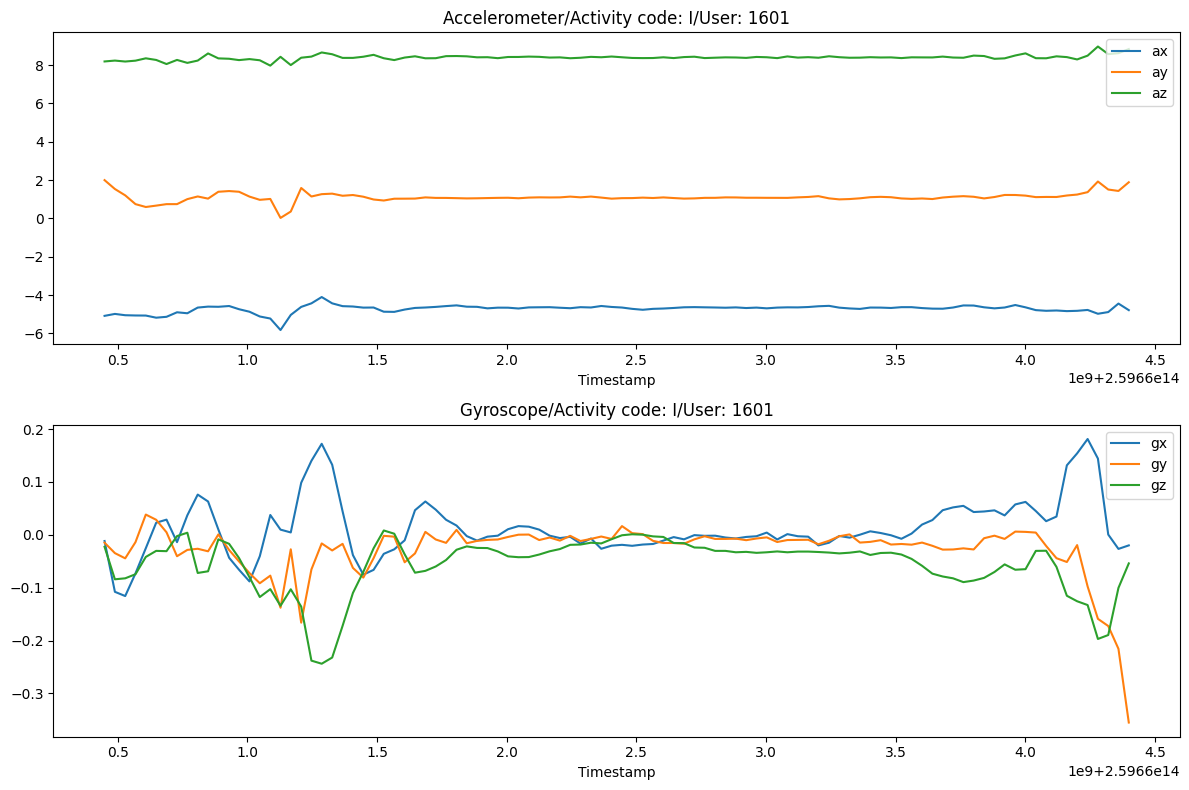

In [118]:
visualize_sensors(100,'I',1600)
visualize_sensors(100,'I',1601)

It is appearent that less demanding activity produces less acceleration, However we still have pretty active gyroscope which indicates, that eating chips needs a lot of rotation motion. This is also a pattern to be learned.

### PART 2.2: Data preprocessing

Time series data is hard for the model to train on. In our case a single data point only contains 6 coordinates, 3 for accelerometer and 3 for gyroscope. So, in a single datapoint we only have 2 dots in the 3D space, that will not give model any useful information. For the model to actually extract useful patterns from our dataset, we need to split the data into equal sized windows. This way model can interpret a single window as an activity spanning some amount of time. It may be easier for us to think that a single data point is a snapshot and one window is a small collection of snapshots, like a movie. 

### defining window splitter function and determining optimal window size
Since single activity is being measured for **3 minutes(180 seconds)** and frequency is **20Hz(20 measurements per second)**, We would have around **3600 measurements** per activity per person. So if we set window size to 3600 we would get 3 minutes of data in a single window. We do not want that, since Our chosen model, which is 1D convolutional neural network, needs small enough windows with 1 to 3 seconds of data to properly discover patterns inside our dataset. so we determined the optimal size of the windows to be **3 seconds** wide so **60 measurements per window**.

the function below creates size 60 windows with step size 60 and it creates them based on activity code and user_id.
the **if** clause makes sure that data in a single window is from only one person and has only one activity code attached. Function returns 2 numpy arrays.

In [ ]:
def create_windows(dataframe, window_size=60, step_size=60):
    X_list = []
    y_list = []
    for i in range(0, len(dataframe) - window_size, step_size):
        window = dataframe.iloc[i : i + window_size]

        
        if window['activity_code'].nunique() == 1 and window['user_id'].nunique() == 1:
            features = window[['ax', 'ay', 'az','gx','gy','gz']].values
            label = window['activity_code'].iloc[0]

            X_list.append(features)
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

In [97]:
X_raw, y_raw = create_windows(final_df)

In [98]:
X_raw.shape

(47684, 60, 6)

In [109]:
y_raw.shape

(47684,)

the result is 3D tensor for X_raw where we have 47684 windows which are size 60 and have 6 features for each data point inside them.
and for y_raw we have 1D tensor.

Since model cant understand letters as categories, we are first using lable encoder to transform activity codes into numbers from 0 to 17 and then using to_categorical function to do one-hot encoding.

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
num_classes = len(np.unique(y_encoded))


y_categorical = to_categorical(y_encoded, num_classes=num_classes)


  



Here we split the data into training and testing splits where train size is 70% and test size is 30. we also stratify to preserve the class distribution in both train and test split. Since our dataset is imbalanced this is a cruical step, because without stratify, The model might train mostly on common activities.

After the split we are scaling features with standard scaler. but before that we are reshaping our data to be fitted on standard scaler and actually scale values. after scaling we switch back to normal dimentions.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_categorical, test_size=0.3, random_state=5, stratify=y_encoded
)

window_count_train,timesteps_train,feature_count_train = X_train.shape
window_count_test,timesteps_test,feature_count_test = X_test.shape

X_train_2D = X_train.reshape(-1,feature_count_train)
X_test_2D = X_test.reshape(-1,feature_count_test)

scaler = StandardScaler()
scaler.fit(X_train_2D)
X_train_scaled = scaler.transform(X_train_2D)
X_test_scaled = scaler.transform(X_test_2D)

X_train_scaled = X_train_scaled.reshape(window_count_train,timesteps_train,feature_count_train)
X_test_scaled = X_test_scaled.reshape(window_count_test,timesteps_test,feature_count_test)

In [117]:
print(f'x_train shape: {X_train_scaled.shape}    y_train shape: {y_train.shape}')
print(f'x_test shape: {X_test_scaled.shape}    y_test shape: {y_test.shape}')

x_train shape: (33378, 60, 6)    y_train shape: (33378, 18)
x_test shape: (14306, 60, 6)    y_test shape: (14306, 18)


Now the data is ready to be fed into the model

## PART 3: Building a model, training and evaluation

We built a 5 layer 1D CNN, first two conv1D layers have 64 filters, which would learn 64 patterns simultaneously on each layer, then we pass the tensor through maxPooling layer of size 2 esentially halfing timesteps, then we do dropout of 20% to prevent overfitting. second conv1D layer is for deeper patterns and has 128 patterns to learn. then maxpooling again and dropout of 30% because deeper layers have much higher chance of overfitting. lastly we flatten the tensor into 1D for dense categorization, after flattening we pass into dense layer to learn which combinations of extracted features correspond to which activities and we have a dropout of 50%. and finally we have a last dense layer which has the size of 18 and has softmax activation which assigns normalized probabilities to our 18 activity codes.

after that we compile our model with adam optimizer, which adjusts how big each weight update is per parameter. we use categorical_crossentropy loss to heavily penalize highly confident wrong predictions and we use accuracy as a main metric to determine model's correctness.

In [ ]:
model = Sequential([
    
    Conv1D(filters=64, kernel_size=3,activation='relu', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Conv1D(filters=64, kernel_size=3,activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

   
    Conv1D(filters=128, kernel_size=3,activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    
    Dense(X_train_scaled.shape[2], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Compiling 1D-CNN Model...


c:\Users\David\miniconda3\envs\ai_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 56, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       213,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,714 (991.07 KB)

 Trainable params: 253,714 (991.07 KB)

 Non-trainable params: 0 (0.00 B)

Here we define early stopping parameter and auto reducing learning rate to prevent model from overfitting and reduce learning rate if there is no improvement(if model takes steps that are too large). Both monitor val_loss and they have patience of 7 and 3, where early stopping waits for 7 epochs before ending the training and LR waits for 3 epochs to reduce learning rate.

we fit the model with the data and we have 100 epochs, default batch_size and validation split of 15% to further prevent overfitting. Ofcourse we also use previously defined callbacks.

In [ ]:


early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=7,                
    restore_best_weights=True  
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,                
    patience=3,                
    min_lr=1e-6
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n==========================================")
print(f"Training Complete!")
print(f"Model Accuracy on Test Set: {test_acc * 100:.2f}%")
print(f"==========================================")


print("\nClass Mapping Reference:")
for index, class_label in enumerate(label_encoder.classes_):
    print(f"Index {index} corresponds to Activity Code: {class_label}")

Epoch 1/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2053 - loss: 2.2628 - val_accuracy: 0.3008 - val_loss: 1.9672 - learning_rate: 0.0010
Epoch 2/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3125 - loss: 1.9291 - val_accuracy: 0.3711 - val_loss: 1.8082 - learning_rate: 0.0010
Epoch 3/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3606 - loss: 1.7890 - val_accuracy: 0.3992 - val_loss: 1.6748 - learning_rate: 0.0010
Epoch 4/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3937 - loss: 1.6906 - val_accuracy: 0.4532 - val_loss: 1.5795 - learning_rate: 0.0010
Epoch 5/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4217 - loss: 1.6164 - val_accuracy: 0.4657 - val_loss: 1.5241 - learning_rate: 0.0010
Epoch 6/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4449 - loss: 1.5500 - val_accuracy: 0.4733 - val_loss: 1.4889 - learning_rate: 0.0010
Epoch 7/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.4641 - loss: 

### Evaluation

It appears that early stopping did not detect stagnant learning and did not stop the process. at the end we got accuracy on test set of 79.81% which is fairly good for time series data model with 18 classes.

To evaluate model further, we used confusion matrix and saw that we have substantionally low missclassifications.

448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


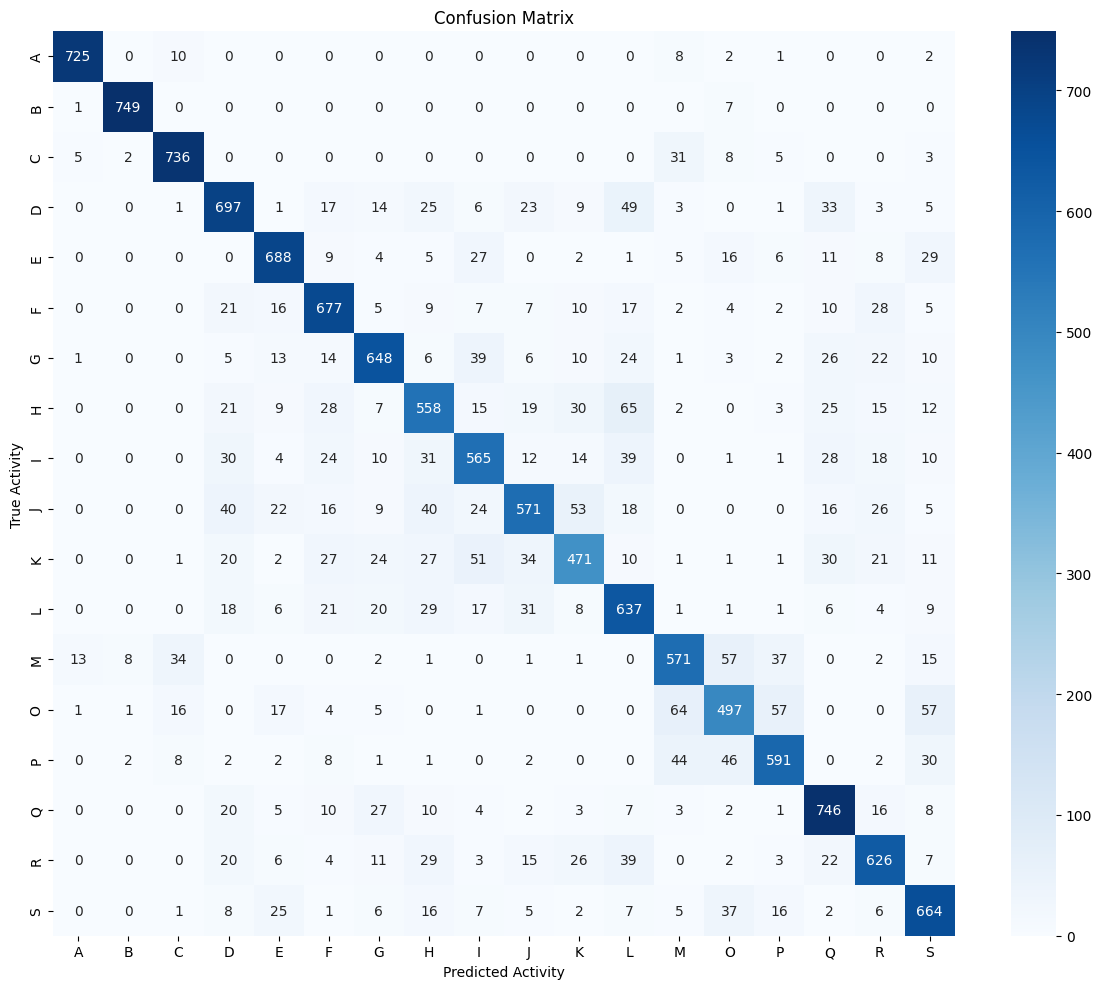

              precision    recall  f1-score   support

           A       0.97      0.97      0.97       748
           B       0.98      0.99      0.99       757
           C       0.91      0.93      0.92       790
           D       0.77      0.79      0.78       887
           E       0.84      0.85      0.85       811
           F       0.79      0.83      0.81       820
           G       0.82      0.78      0.80       830
           H       0.71      0.69      0.70       809
           I       0.74      0.72      0.73       787
           J       0.78      0.68      0.73       840
           K       0.74      0.64      0.69       732
           L       0.70      0.79      0.74       809
           M       0.77      0.77      0.77       742
           O       0.73      0.69      0.71       720
           P       0.81      0.80      0.81       739
           Q       0.78      0.86      0.82       864
           R       0.79      0.77      0.78       813
           S       0.75    

In [ ]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = np.argmax(y_test, axis=1)


cm = confusion_matrix(y_true, y_pred)


class_names = label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


print(classification_report(y_true, y_pred, target_names=class_names))

We also looked at accuracy history for both training and validation set and the plot looks very healthy. it even shows the spike when learning rate changed. Validation curve is slightly further up than training curve which shows that model generalizes well on unseen data.

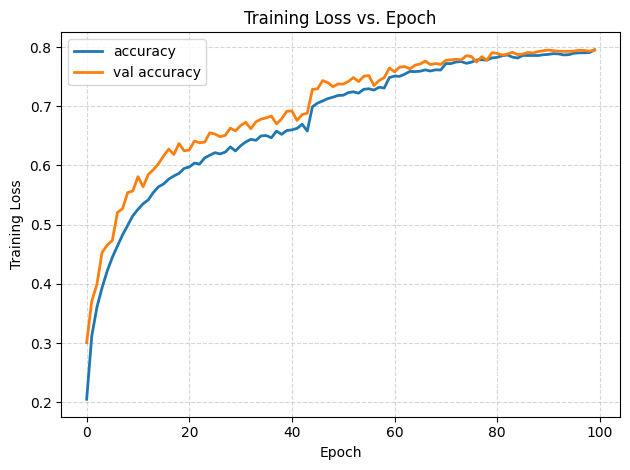

In [108]:
plt.plot( history.history['accuracy'], label='accuracy', linewidth=2)
plt.plot( history.history['val_accuracy'], label='val accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epoch')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend ()
plt.tight_layout()
plt.show()